csherwood@usgs.gov, 2026-09-18, generated with Claude Sonnet 5

# Optical wave gauging: modern re-implementation

Re-implements the transfer-learning regression approach of Buscombe et al. (2019),
*Optical wave gauging using deep neural networks*, Coastal Engineering 150, 1-6,
https://doi.org/10.1016/j.coastaleng.2019.103593, using PyTorch + `timm` instead
of the original TF1/Keras `MobileNet`/`InceptionV3`/`InceptionResNetV2`/`DenseNet201`
implementation (https://github.com/dbuscombe-usgs/OpticalWaveGauging_DNN).

Dataset: nearshore oblique camera-2 snapshot imagery, Duck NC (`Nearshore-Training-Oblique-cam2-snap.csv`,
1030 images, ~257 MB zip). Two separate models are fine-tuned, one each for significant wave
height $H$ (m) and peak period $T$ (s), each a scalar regression head on a single
ImageNet-pretrained CNN backbone.

Key change from the original: the backbone is loaded **with pretrained ImageNet weights**
(the original used `weights=None`, i.e. trained from scratch, which the pretrained-architecture
choice was not actually exploiting). Images are decoded as 3-channel RGB (not converted to
grayscale) so the pretrained stem still receives a normal 3-channel input.

In [1]:
# config
DATA_DIR       = "F:/crs/src/OpticalWaveGauging_DNN"
IMAGE_DIR      = f"{DATA_DIR}/snap/data"
CSV_PATH        = "F:/crs/src/OpticalWaveGauging_DNN/Nearshore-Training-Oblique-cam2-snap.csv"

CATEGORIES     = ["H", "T"]          # wave height (m), wave period (s)
IMG_SIZE       = 224                 # square input, pixels
BACKBONE       = "convnext_tiny"     # timm model name, ImageNet-pretrained
TEST_SIZE      = 0.3                 # fraction held out for validation
BATCH_SIZE     = 32
NUM_EPOCHS     = 40
FREEZE_EPOCHS  = 5                   # epochs with backbone frozen before unfreezing
LR_HEAD        = 1e-3                # lr while backbone is frozen
LR_FINETUNE    = 1e-4                # lr after unfreezing
WEIGHT_DECAY   = 1e-4
PATIENCE       = 10                  # early-stopping patience (epochs, on val loss)
NUM_WORKERS    = 0                   # >0 hangs/crashes in Jupyter on Windows (spawn re-imports the notebook)
DEVICE_H       = "cuda:0"            # train H on GPU 0
DEVICE_T       = "cuda:1"            # train T on GPU 1 (set equal to DEVICE_H if only 1 GPU used)
RANDOM_STATE   = 2018                # matches original repo's train_test_split seed
OUT_DIR        = "owg_out"


In [2]:
import os, time, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
from PIL import Image
import timm

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
print(torch.__version__, "cuda available:", torch.cuda.is_available(), "device count:", torch.cuda.device_count())


2.14.0+cu126 cuda available: True device count: 2


## Labels

Same column names ( `id`, `H`, `T` ) and stratified train/val split (by
`pd.cut` bins of the target) as the original repo, so results are roughly
comparable. `path` points at the actual image file for each row.

In [3]:
df = pd.read_csv(CSV_PATH)
df = df.rename(columns=lambda c: c.strip())
df["path"] = df["id"].map(lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg"))
df = df[df["path"].map(os.path.exists)].dropna().reset_index(drop=True)
print(df.shape)
df.head()


(968, 4)


,id,H,T,path
0,1512588600.c2.snap,0.60,15.66,F:/crs/src/OpticalWaveGauging_DNN/snap/data\15...
1,1512590400.c2.snap,0.58,15.64,F:/crs/src/OpticalWaveGauging_DNN/snap/data\15...
2,1512592200.c2.snap,0.56,15.62,F:/crs/src/OpticalWaveGauging_DNN/snap/data\15...
3,1512594000.c2.snap,0.56,15.18,F:/crs/src/OpticalWaveGauging_DNN/snap/data\15...
4,1512595800.c2.snap,0.57,14.75,F:/crs/src/OpticalWaveGauging_DNN/snap/data\15...


In [4]:
class OWGDataset(Dataset):
    def __init__(self, df, category, img_size, train):
        self.paths = df["path"].values
        self.y = df[category].values.astype(np.float32)
        if train:
            self.tf = T.Compose([
                T.ToImage(), T.Resize((img_size, img_size)),
                T.RandomHorizontalFlip(),
                T.RandomAffine(degrees=10, translate=(0.1, 0.1), shear=5),
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        else:
            self.tf = T.Compose([
                T.ToImage(), T.Resize((img_size, img_size)),
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        x = self.tf(img)
        y = torch.tensor(self.y[idx])
        return x, y


## Model

ImageNet-pretrained backbone (`timm.create_model(..., pretrained=True)`) with a
single linear regression head, e.g. ConvNeXt (Liu et al., 2022, *A ConvNet for
the 2020s*, https://arxiv.org/abs/2201.03545) — swap `BACKBONE` for any `timm`
model, e.g. `"tf_efficientnetv2_s"` (Tan & Le, 2021, *EfficientNetV2: Smaller
Models and Faster Training*, https://arxiv.org/abs/2104.00298).

Training is two-stage: backbone frozen for `FREEZE_EPOCHS` (head-only, higher
LR), then unfrozen for full fine-tuning at a lower LR — this generalizes much
better than training the backbone from scratch (`weights=None`, as in the
original repo) on O(10^3) images.

In [5]:
def build_model():
    m = timm.create_model(BACKBONE, pretrained=True, num_classes=1)
    return m

def set_backbone_trainable(model, trainable):
    for name, p in model.named_parameters():
        if "head" not in name and "fc" not in name and "classifier" not in name:
            p.requires_grad = trainable


In [6]:
def train_owg(category, device):
    train_df, val_df = train_test_split(
        df, test_size=TEST_SIZE, random_state=RANDOM_STATE,
        stratify=pd.cut(df[category], 10 if category == "H" else 8))

    train_ds = OWGDataset(train_df, category, IMG_SIZE, train=True)
    val_ds   = OWGDataset(val_df,   category, IMG_SIZE, train=False)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = build_model().to(device)
    loss_fn = nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, bad_epochs = np.inf, None, 0

    for epoch in range(NUM_EPOCHS):
        finetune = epoch >= FREEZE_EPOCHS
        set_backbone_trainable(model, finetune)
        if epoch in (0, FREEZE_EPOCHS):
            opt = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=LR_FINETUNE if finetune else LR_HEAD, weight_decay=WEIGHT_DECAY)
            sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3)

        model.train()
        tr_loss = 0.0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            pred = model(x).squeeze(1)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(y)
        tr_loss /= len(train_ds)

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                pred = model(x).squeeze(1)
                va_loss += loss_fn(pred, y).item() * len(y)
        va_loss /= len(val_ds)
        sched.step(va_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        print(f"[{category}] epoch {epoch:02d}  train_mse {tr_loss:.4f}  val_mse {va_loss:.4f}")

        if va_loss < best_val:
            best_val, best_state, bad_epochs = va_loss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"[{category}] early stop at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    torch.save(best_state, f"{OUT_DIR}/owg_{category}_{BACKBONE}.pt")

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_dl:
            pred = model(x.to(device)).squeeze(1).cpu().numpy()
            y_true.append(y.numpy()); y_pred.append(pred)
    y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

    return model, history, y_true, y_pred


## Train H and T

Runs sequentially here for clarity (portable to a single GPU); on the two-GPU
box, launch as two separate processes with `DEVICE_H="cuda:0"` /
`DEVICE_T="cuda:1"` to overlap them instead.

In [7]:
results = {}
devices = {"H": DEVICE_H, "T": DEVICE_T}
for category in CATEGORIES:
    device = devices[category] if torch.cuda.is_available() else "cpu"
    model, history, y_true, y_pred = train_owg(category, device)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{category}] val RMSE {rmse:.3f}  R2 {r2:.3f}")
    results[category] = dict(history=history, y_true=y_true, y_pred=y_pred, rmse=rmse, r2=r2)


[H] epoch 00  train_mse 15.6638  val_mse 0.3267
[H] epoch 01  train_mse 0.2544  val_mse 0.2463
[H] epoch 02  train_mse 0.2517  val_mse 0.2378
[H] epoch 03  train_mse 0.2457  val_mse 0.2294
[H] epoch 04  train_mse 0.2682  val_mse 0.2350
[H] epoch 05  train_mse 0.2701  val_mse 0.2314
[H] epoch 06  train_mse 0.2472  val_mse 0.2448
[H] epoch 07  train_mse 0.2605  val_mse 0.3159
[H] epoch 08  train_mse 0.2876  val_mse 0.2334
[H] epoch 09  train_mse 0.2461  val_mse 0.2440
[H] epoch 10  train_mse 0.2440  val_mse 0.2206
[H] epoch 11  train_mse 0.2282  val_mse 0.2043
[H] epoch 12  train_mse 0.2040  val_mse 0.2015
[H] epoch 13  train_mse 0.1946  val_mse 0.2133
[H] epoch 14  train_mse 0.1847  val_mse 0.1831
[H] epoch 15  train_mse 0.1722  val_mse 0.1830
[H] epoch 16  train_mse 0.1678  val_mse 0.1796
[H] epoch 17  train_mse 0.1721  val_mse 0.1839
[H] epoch 18  train_mse 0.1885  val_mse 0.1646
[H] epoch 19  train_mse 0.1593  val_mse 0.1541
[H] epoch 20  train_mse 0.1655  val_mse 0.1677
[H] epoch 21

## Results

Predicted vs. observed for both targets. $\mathrm{RMSE}$ and $R^2$ are computed
on the held-out validation split.

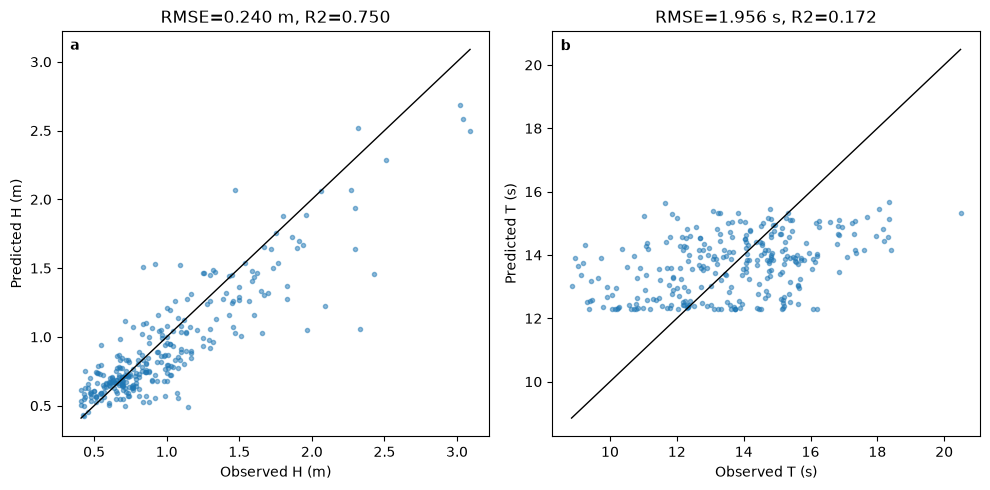

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
labels = ["a", "b"]
units = {"H": "m", "T": "s"}
for ax, category, label in zip(axs, CATEGORIES, labels):
    r = results[category]
    lims = [min(r["y_true"].min(), r["y_pred"].min()), max(r["y_true"].max(), r["y_pred"].max())]
    ax.plot(r["y_true"], r["y_pred"], ".", alpha=0.5)
    ax.plot(lims, lims, "k-", lw=1)
    ax.set_xlabel(f"Observed {category} ({units[category]})")
    ax.set_ylabel(f"Predicted {category} ({units[category]})")
    ax.set_title(f"RMSE={r['rmse']:.3f} {units[category]}, R2={r['r2']:.3f}")
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
fig.tight_layout()


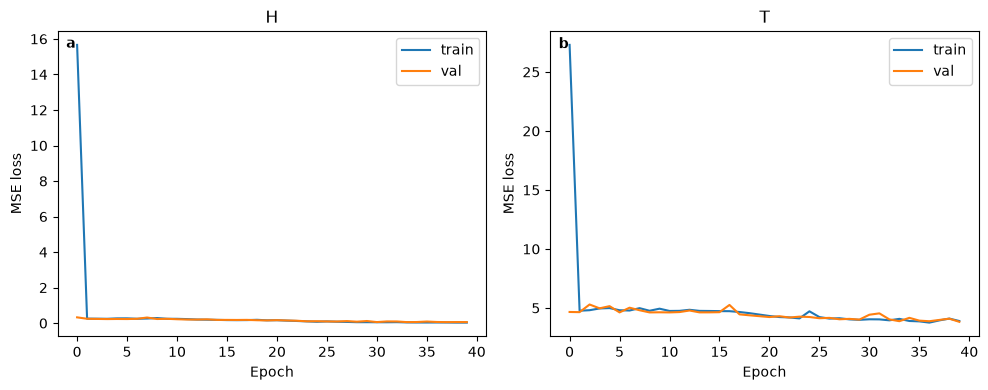

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
labels = ["a", "b"]
for ax, category, label in zip(axs, CATEGORIES, labels):
    h = results[category]["history"]
    ax.plot(h["train_loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title(category)
    ax.legend()
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
fig.tight_layout()
